In [ ]:
from joblib import Parallel, delayed
from tqdm import tqdm
from sklearn.metrics import mean_squared_error

In [2]:
from utils import DataHandler
from ESN import ESNetwork
from reservoirs import CPRC

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def echo_state_test(input_data, dim, alpha, limit):
    # Define two independent ESN instances with same input
    CP_params = [0.1499956344663278, np.pi/7, -np.pi/3, 7*np.pi/7, np.pi/9, -np.pi/7]
    r1 = CPRC(dim=dim, execution_mode='simulation', CP_params=CP_params, kernel=True)
    esn1 = ESNetwork(reservoir=r1, dim=dim, alpha=alpha, regularization=1e-6,
                     approach='feedback', limit=limit, model_type='ridge', cpk=True)

    r2 = CPRC(dim=dim, execution_mode='simulation', CP_params=CP_params, kernel=True)
    esn2 = ESNetwork(reservoir=r2, dim=dim, alpha=alpha, regularization=1e-6,
                     approach='feedback', limit=limit, model_type='ridge', cpk=True)

    esn1.prev_output = np.random.rand(esn1.dim)
    esn2.prev_output = np.zeros(esn2.dim) #np.random.rand(esn2.dim)

    # Feed the same input into both, suppress training
    esn1.fit(input_data, np.zeros(len(input_data)), washout=0)
    states1 = esn1.get_saved_states()

    esn2.fit(input_data, np.zeros(len(input_data)), washout=0)
    states2 = esn2.get_saved_states()

    # Compute Euclidean distance between reservoir states over time
    min_len = min(len(states1), len(states2))
    dist = np.linalg.norm(np.array(states1[:min_len]) - np.array(states2[:min_len]), axis=1)
    return dist


In [11]:
X, Y = DataHandler().load_dataset('mackey_glass', n_samples=5000, tau=17, window_size=20, prediction_horizon=1, plot=False)
dim = X.shape[1]

In [12]:
dist = echo_state_test(X, dim=20, alpha=0.79, limit=0.95)

Training Progress: 100%|██████████| 4980/4980 [10:37<00:00,  7.81 sample/s]  


In [13]:
dist
# array([0.02432159, 0.00604479, 0.00171264, ..., 0.        , 0.        ,
       # 0.        ])

array([0.0516954 , 0.01424747, 0.00574054, ..., 0.        , 0.        ,
       0.        ], shape=(4980,))

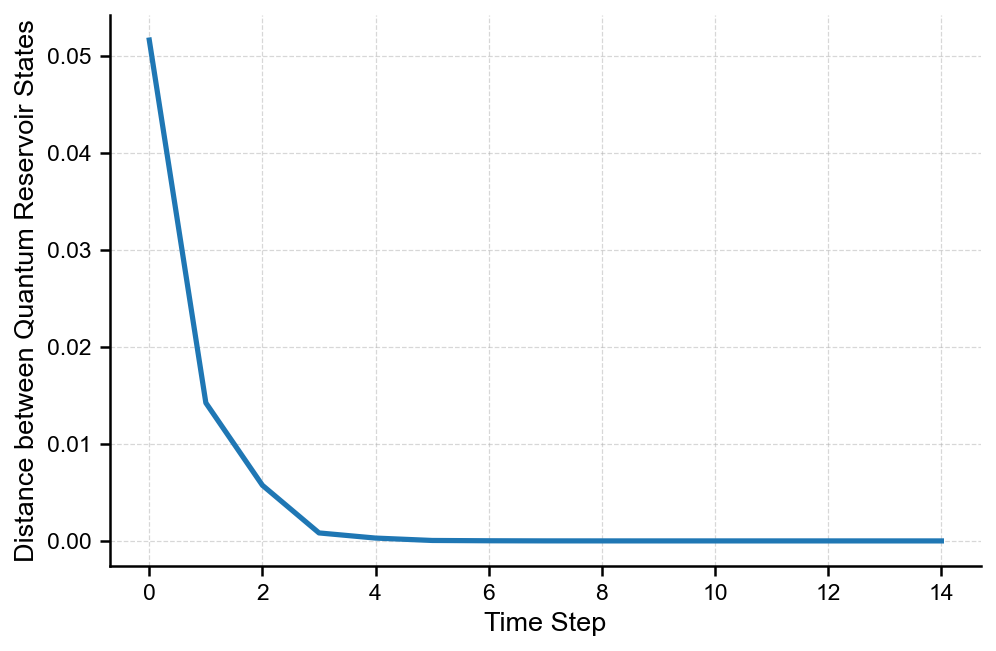

In [14]:
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({
    # ── Font ──────────────────────────────────────────────────
    "font.family":        "sans-serif",
    "font.sans-serif":    ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size":          12,          # base size for tick labels
    "axes.titlesize":     14,          # subplot title
    "axes.labelsize":     13,          # x/y axis labels
    "legend.fontsize":    11,
    "xtick.labelsize":    11,
    "ytick.labelsize":    11,

    # ── Line thickness ────────────────────────────────────────
    "lines.linewidth":    2.5,         # matches the chart line width
    "lines.markersize":   8,           # matches marker size

    # ── Axes ──────────────────────────────────────────────────
    "axes.linewidth":     1.2,
    "axes.spines.top":    False,       # clean look — no top/right border
    "axes.spines.right":  False,
    "axes.grid":          True,
    "grid.alpha":         0.3,
    "grid.linewidth":     0.6,

    # ── Ticks ─────────────────────────────────────────────────
    "xtick.major.width":  1.2,
    "ytick.major.width":  1.2,
    "xtick.major.size":   5,
    "ytick.major.size":   5,
    "xtick.direction":    "out",
    "ytick.direction":    "out",

    # ── Figure / output ───────────────────────────────────────
    "figure.dpi":         150,         # screen preview
    "savefig.dpi":        300,         # print/paper quality
    "savefig.bbox":       "tight",
    "savefig.format":     "pdf",       # vector — best for papers
})


plt.figure(figsize=(6.8, 4.5))
plt.plot(dist[:15], label='State distance')
plt.xlabel("Time Step")
plt.ylabel("Distance between Quantum Reservoir States")
# plt.title("Echo State Property in Quantum Reservoir")
plt.grid(True, linestyle='--', alpha=0.5)
# plt.legend()
plt.tight_layout()
# plt.savefig("figures/echo_state_test_qrc.pdf")
plt.show()

In [10]:
dist

array([0.02432159, 0.00604479, 0.00171264, ..., 0.        , 0.        ,
       0.        ])

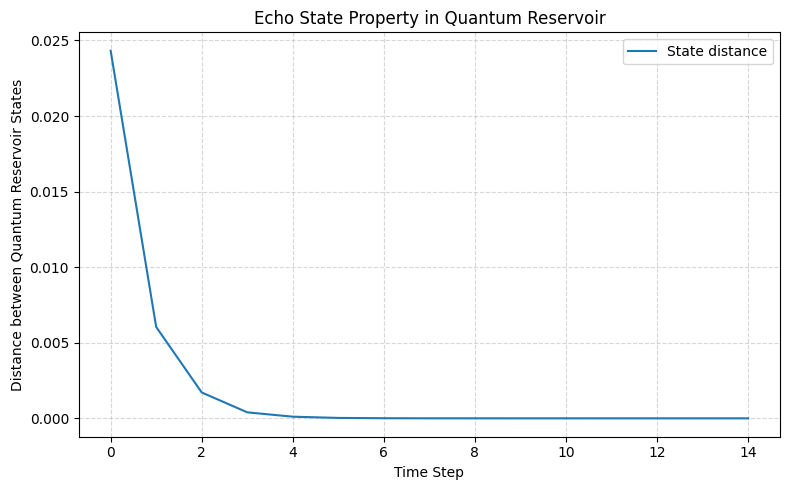

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(dist[:15], label='State distance')
plt.xlabel("Time Step")
plt.ylabel("Distance between Quantum Reservoir States")
plt.title("Echo State Property in Quantum Reservoir")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
# plt.savefig("figures/echo_state_test_qrc.pdf")
plt.show()

In [15]:
def test_esp(input_data, dim, alpha, limit, threshold=1e-3, itr=None, verbose=True):
    if verbose and itr is not None:
        print(f"Running trial {itr}: alpha = {alpha:.2f}, limit = {limit:.2f}")
    r1 = CPRC(dim=dim, execution_mode='simulation', kernel=True)
    esn1 = ESNetwork(reservoir=r1, dim=dim, alpha=alpha, regularization=1e-6,
                     approach='feedback', limit=limit, model_type='ridge', cpk=True)

    r2 = CPRC(dim=dim, execution_mode='simulation', kernel=True)
    esn2 = ESNetwork(reservoir=r2, dim=dim, alpha=alpha, regularization=1e-6,
                     approach='feedback', limit=limit, model_type='ridge', cpk=True)

    esn1.prev_output = np.random.rand(esn1.dim)
    esn2.prev_output = np.zeros(esn2.dim) #np.random.rand(esn2.dim)

    # Feed the same input into both, suppress training
    esn1.fit(input_data, np.zeros(len(input_data)), washout=0)
    states1 = esn1.get_saved_states()

    esn2.fit(input_data, np.zeros(len(input_data)), washout=0)
    states2 = esn2.get_saved_states()

    # Compute Euclidean distance between reservoir states over time
    min_len = min(len(states1), len(states2))
    dist = np.linalg.norm(np.array(states1[:min_len]) - np.array(states2[:min_len]), axis=1)
    final_distance= dist[-1]
    return {
        "alpha": alpha,
        "limit": limit,
        "esp": final_distance < threshold,
        "final_distance": final_distance
    }


In [16]:
alphas = np.linspace(0.1, 1.0, 10)
limits = np.linspace(0.1, 1.0, 10)

X, Y = DataHandler().load_dataset('mackey_glass', n_samples=10000, tau=17, window_size=20, prediction_horizon=1, plot=False)
input_signal = X  # choose one time channel
dim = X.shape[1]

# Sweep alpha–limit pairs
grid = [(a, l) for a in alphas for l in limits]

results = Parallel(n_jobs=-1)(
    delayed(test_esp)(input_signal, dim ,alpha, limit, itr=i)
    for i, (alpha, limit) in enumerate(tqdm(grid, desc="Running ESP tests"))
)




ning ESP tests:  12%|██▊                    | 12/100 [00:00<00:03, 24.70it/s]

Running trial 5: alpha = 0.10, limit = 0.60
Running trial 1: alpha = 0.10, limit = 0.20
Running trial 2: alpha = 0.10, limit = 0.30
Running trial 0: alpha = 0.10, limit = 0.10
Running trial 4: alpha = 0.10, limit = 0.50
Running trial 6: alpha = 0.10, limit = 0.70


Training Progress:   0%|          | 1/9980 [00:00<54:21,  3.06 sample/s]

Running trial 3: alpha = 0.10, limit = 0.40
Running trial 7: alpha = 0.10, limit = 0.80


Training Progress: 100%|██████████| 9980/9980 [50:58<00:00,  3.26 sample/s]  

Training Progress:  98%|█████████▊| 9746/9980 [50:09<01:26,  2.70 sample/s]s/it]

...

Training Progress:  74%|███████▍  | 7390/9980 [19:31<12:30,  3.45 sample/s]

Running trial 98: alpha = 1.00, limit = 0.90


Training Progress:   2%|▏         | 193/9980 [00:36<29:54,  5.45 sample/s]]

Running trial 99: alpha = 1.00, limit = 1.00


Training Progress: 100%|██████████| 9980/9980 [15:21<00:00, 10.84 sample/s]


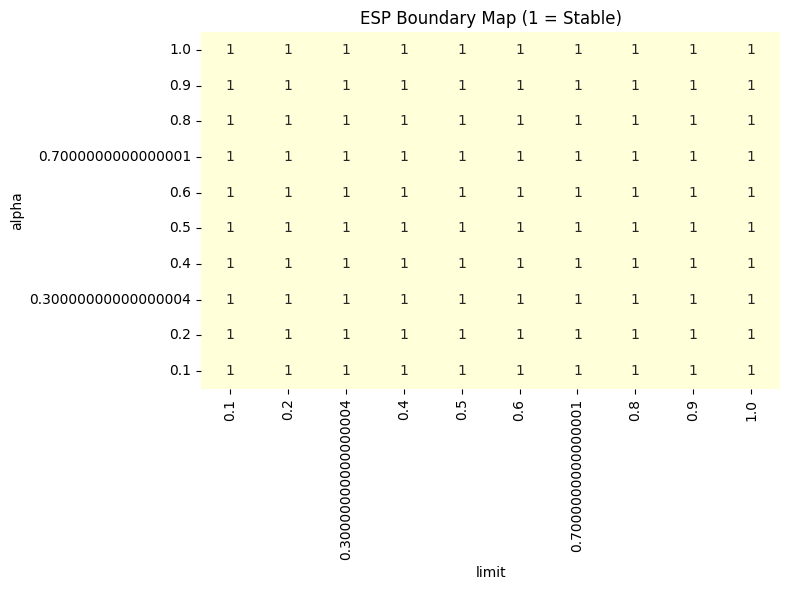

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create DataFrame
df = pd.DataFrame(results)

# Pivot for heatmap
pivot = df.pivot(index="alpha", columns="limit", values="esp")
pivot = pivot.sort_index(ascending=False)  # to get lower-left origin

plt.figure(figsize=(8, 6))
sns.heatmap(pivot, cmap="YlGnBu", annot=True, fmt="d", cbar=False)
plt.title("ESP Boundary Map (1 = Stable)")
plt.xlabel("limit")
plt.ylabel("alpha")
plt.tight_layout()
# plt.savefig("esp_boundary_parallel.pdf")
plt.show()


In [18]:
results

[{'alpha': np.float64(0.1),
  'limit': np.float64(0.1),
  'esp': np.True_,
  'final_distance': np.float64(0.0)},
 {'alpha': np.float64(0.1),
  'limit': np.float64(0.2),
  'esp': np.True_,
  'final_distance': np.float64(0.0)},
 {'alpha': np.float64(0.1),
  'limit': np.float64(0.30000000000000004),
  'esp': np.True_,
  'final_distance': np.float64(0.0)},
 {'alpha': np.float64(0.1),
  'limit': np.float64(0.4),
  'esp': np.True_,
  'final_distance': np.float64(0.0)},
 {'alpha': np.float64(0.1),
  'limit': np.float64(0.5),
  'esp': np.True_,
  'final_distance': np.float64(0.0)},
 {'alpha': np.float64(0.1),
  'limit': np.float64(0.6),
  'esp': np.True_,
  'final_distance': np.float64(0.0)},
 {'alpha': np.float64(0.1),
  'limit': np.float64(0.7000000000000001),
  'esp': np.True_,
  'final_distance': np.float64(0.0)},
 {'alpha': np.float64(0.1),
  'limit': np.float64(0.8),
  'esp': np.True_,
  'final_distance': np.float64(0.0)},
 {'alpha': np.float64(0.1),
  'limit': np.float64(0.9),
  'esp': 

In [21]:
df.to_csv("figures/esp_grid_results.csv", index=False)